In [1]:
import numpy as np
import os
import glob
import json
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import levene
from itertools import combinations
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style
set_thesis_style()

# Analysis

## Model data

Single-Source:
  Mean: 1.2865
  Median: 1.2549
  Variance: 0.0313
  Standard Deviation: 0.1771

Multi-Source:
  Mean: 1.4586
  Median: 1.3539
  Variance: 0.1701
  Standard Deviation: 0.4125

Human-Source:
  Mean: 3766.9777
  Median: 2.5005
  Variance: 12211648516.7976
  Standard Deviation: 110506.3279

None (Vanilla):
  Mean: 1.3809
  Median: 1.2847
  Variance: 0.1686
  Standard Deviation: 0.4106



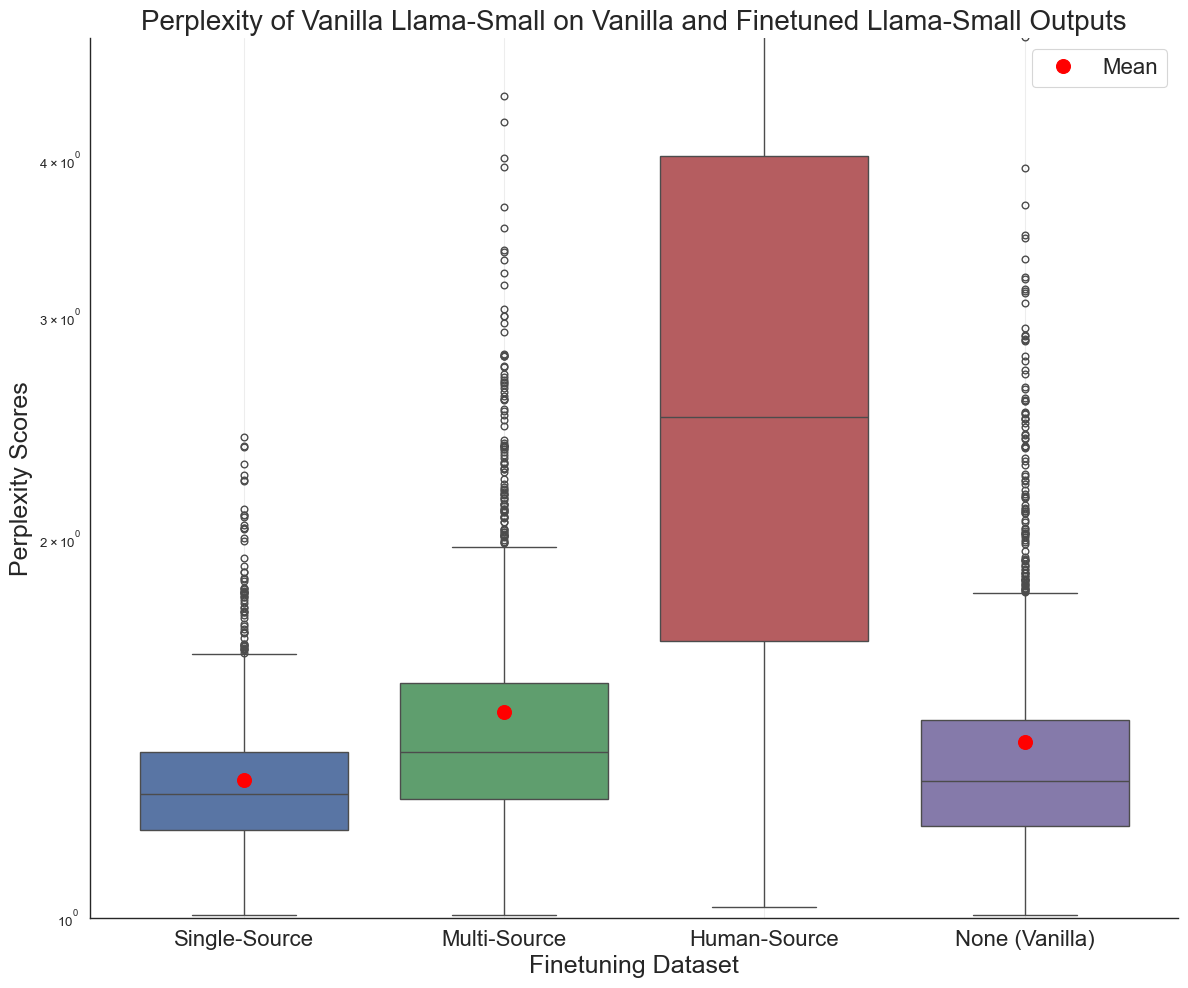

In [25]:
# Get all perplexity files
ppl_files_small = glob.glob("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity/ppl*.jsonl")
ppl_files_medium = glob.glob("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/ppl*.jsonl")

# Define datasets in desired order with their corresponding filenames
datasets = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("Multi-Source", "ppl_lora_llama_8b_multi.jsonl"),
    ("Human-Source", "ppl_lora_llama_8b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

# Create set of target filenames for quick lookup
target_files = {filename for _, filename in datasets}

# Extract perplexity values
perplexities_by_file = {}
for file in ppl_files_small:
    file_name = os.path.basename(file)
    if file_name in target_files:
        perplexities_by_file[file_name] = []
        with open(file, 'r') as f:
            for line in f:
                data = json.loads(line)
                perp = data["token_probabilities"]["perplexity"]
                perplexities_by_file[file_name].append(perp)

# Prepare data for plotting
boxplot_data = []
boxplot_labels = []
mean_perplexities = {}

for dataset_name, file_name in datasets:
    if file_name in perplexities_by_file:
        perplexities = perplexities_by_file[file_name]
        
        # Add to boxplot data
        boxplot_data.extend(perplexities)
        boxplot_labels.extend([dataset_name] * len(perplexities))
        
        # Calculate and store statistics
        mean_val = np.mean(perplexities)
        median_val = np.median(perplexities)
        variance = np.var(perplexities)
        mean_perplexities[dataset_name] = mean_val
        
        print(f"{dataset_name}:")
        print(f"  Mean: {mean_val:.4f}")
        print(f"  Median: {median_val:.4f}")
        print(f"  Variance: {variance:.4f}")
        print(f"  Standard Deviation: {np.sqrt(variance):.4f}")
        print()

# Create the plot
plt.figure(figsize=(12, 10))
sns.boxplot(x=boxplot_labels, y=boxplot_data, palette=sns.color_palette()[:4], hue=boxplot_labels)

# Add mean points
for i, (dataset_name, _) in enumerate(datasets):
    if dataset_name in mean_perplexities:
        plt.plot(i, mean_perplexities[dataset_name], 'o', color='red', markersize=10, 
                label='Mean' if i == 0 else "")

# Styling
plt.xlabel('Finetuning Dataset', fontsize=18)
plt.ylabel('Perplexity Scores', fontsize=18)
plt.title('Perplexity of Vanilla Llama-Small on Vanilla and Finetuned Llama-Small Outputs', fontsize=20)
plt.yscale('log')
plt.ylim(1, 5)
plt.grid(alpha=0.7)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.tight_layout()

#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/box_ppl_small_v3.png', dpi=300)
plt.show()

In [17]:
perplexities_by_file.keys()

dict_keys(['ppl_lora_llama_8b_multi.jsonl', 'ppl_lora_llama_8b_human.jsonl', 'ppl_vanilla_llama_8b.jsonl', 'ppl_lora_llama_8b_single.jsonl'])

In [20]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [perplexities for perplexities in perplexities_by_file.values()]
dataset_names = ["Multi-Source", "Human-Source", "None (Vanilla)", "Single-Source"]

H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 2073.78
p-value: 0.00e+00

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

Multi-Source vs Human-Source:
U-statistic: 356625.00
p-value: 4.80e-231
Significant difference: Yes

Multi-Source vs None (Vanilla):
U-statistic: 1354220.50
p-value: 1.77e-21
Significant difference: Yes

Multi-Source vs Single-Source:
U-statistic: 1512813.00
p-value: 5.94e-59
Significant difference: Yes

Human-Source vs None (Vanilla):
U-statistic: 1971688.00
p-value: 5.67e-276
Significant difference: Yes

Human-Source vs Single-Source:
U-statistic: 2044489.50
p-value: 0.00e+00
Significant difference: Yes

None (Vanilla) vs Single-Source:
U-statistic: 1262508.00
p-value: 1.52e-08
Significant difference: Yes


In [19]:
# Define datasets in desired order with their corresponding filenames
datasets = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("Multi-Source", "ppl_lora_llama_8b_multi.jsonl"),
    ("Human-Source", "ppl_lora_llama_8b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

# Organize data by dataset for Levene's test
dataset_perplexities = {}
for dataset_name, file_name in datasets:
    if file_name in perplexities_by_file:
        dataset_perplexities[dataset_name] = perplexities_by_file[file_name]

# Conduct overall Levene's test
print("=" * 60)
print("LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES")
print("=" * 60)

# Prepare data for overall test
all_groups = [dataset_perplexities[name] for name, _ in datasets if name in dataset_perplexities]
group_names = [name for name, _ in datasets if name in dataset_perplexities]

# Overall Levene's test
levene_stat, levene_p = levene(*all_groups)

print(f"Overall Levene's Test:")
print(f"  Groups: {', '.join(group_names)}")
print(f"  Test Statistic: {levene_stat:.6f}")
print(f"  P-value: {levene_p:.6f}")
print(f"  Result: {'Reject H0 (variances are NOT equal)' if levene_p < 0.05 else 'Fail to reject H0 (variances are equal)'}")
print()

# Show individual variances
print("Individual Group Variances:")
for name in group_names:
    variance = np.var(dataset_perplexities[name], ddof=1)  # Sample variance
    print(f"  {name}: {variance:.6f}")
print()

# If overall test is significant, conduct pairwise tests
if levene_p < 0.05:
    print("Since overall test is significant, conducting pairwise Levene's tests:")
    print("-" * 60)
    
    # Pairwise Levene's tests
    pairs = list(combinations(group_names, 2))
    significant_pairs = []
    
    for group1, group2 in pairs:
        group1_data = dataset_perplexities[group1]
        group2_data = dataset_perplexities[group2]
        
        # Conduct pairwise Levene's test
        pair_stat, pair_p = levene(group1_data, group2_data)
        
        # Calculate variances
        var1 = np.var(group1_data, ddof=1)
        var2 = np.var(group2_data, ddof=1)
        
        # Determine result
        is_significant = pair_p < 0.05
        if is_significant:
            significant_pairs.append((group1, group2))
        
        print(f"{group1} vs {group2}:")
        print(f"  Variance 1 ({group1}): {var1:.6f}")
        print(f"  Variance 2 ({group2}): {var2:.6f}")
        print(f"  Variance Ratio: {max(var1, var2) / min(var1, var2):.2f}")
        print(f"  Test Statistic: {pair_stat:.6f}")
        print(f"  P-value: {pair_p:.6f}")
        print(f"  Result: {'Significant difference' if is_significant else 'No significant difference'}")
        print()
    
    # Summary of significant pairs
    if significant_pairs:
        print("Summary - Pairs with significantly different variances:")
        for group1, group2 in significant_pairs:
            var1 = np.var(dataset_perplexities[group1], ddof=1)
            var2 = np.var(dataset_perplexities[group2], ddof=1)
            print(f"  • {group1} (σ² = {var1:.6f}) vs {group2} (σ² = {var2:.6f})")
    else:
        print("No pairwise comparisons showed significant differences.")
else:
    print("Overall test not significant - no pairwise tests needed.")

print("=" * 60)

LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES
Overall Levene's Test:
  Groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
  Test Statistic: 1.742445
  P-value: 0.156011
  Result: Fail to reject H0 (variances are equal)

Individual Group Variances:
  Single-Source: 0.031370
  Multi-Source: 0.170233
  Human-Source: 12219784192.025345
  None (Vanilla): 0.168721

Overall test not significant - no pairwise tests needed.


In [27]:
import numpy as np
from scipy.stats import levene
from itertools import combinations

# =============================================================================
# CRITICAL: Ensure you are using the original, unfiltered perplexity data.
# The 'perplexities_by_file' dictionary should be loaded directly from your 
# JSONL files without any outlier removal steps.
# =============================================================================

# Assuming 'perplexities_by_file' is a dict like:
# {'human_file.jsonl': [2.1, 3.4, 9999999.0, ...], 'single_source_file.jsonl': [1.2, ...]}
# And 'datasets' is a list of tuples like:
# [('Human-Source', 'human_file.jsonl'), ('Single-Source', 'single_source_file.jsonl'), ...]

# Organize the raw data by dataset name for the test
dataset_perplexities = {}
for dataset_name, file_name in datasets:
    if file_name in perplexities_by_file:
        # Important: Use the raw list of perplexities
        dataset_perplexities[dataset_name] = perplexities_by_file[file_name]

# --- Sanity Check: Print group sizes and basic stats before testing ---
print("=" * 60)
print("PRE-TEST DATA CHECK (RAW, UNFILTERED DATA)")
print("=" * 60)
for name, data in dataset_perplexities.items():
    print(f"Group: {name}")
    print(f"  Number of data points: {len(data)}")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  Median: {np.median(data):.4f}")
    print(f"  Variance: {np.var(data, ddof=1):.4f}") # Use ddof=1 for sample variance
    print()

# Prepare data for the test
all_groups = [data for data in dataset_perplexities.values()]
group_names = list(dataset_perplexities.keys())

# --- Perform Levene's Test on the Raw Data ---
print("=" * 60)
print("LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES")
print("=" * 60)

# The test is more robust with the default center='median', which is ideal for skewed data
levene_stat, levene_p = levene(*all_groups)

print(f"Overall Levene's Test:")
print(f"  Groups: {', '.join(group_names)}")
print(f"  Test Statistic: {levene_stat:.6f}")
print(f"  P-value: {levene_p:.6g}") # Using 'g' for scientific notation if p is tiny
print(f"  Result: {'Reject H0 (variances are NOT equal)' if levene_p < 0.05 else 'Fail to reject H0 (variances are equal)'}")
print("=" * 60)

# If the result is now significant, you can proceed with your pairwise analysis.

PRE-TEST DATA CHECK (RAW, UNFILTERED DATA)
Group: Single-Source
  Number of data points: 1502
  Mean: 1.2865
  Median: 1.2549
  Variance: 0.0314

Group: Multi-Source
  Number of data points: 1502
  Mean: 1.4586
  Median: 1.3539
  Variance: 0.1702

Group: Human-Source
  Number of data points: 1502
  Mean: 3766.9777
  Median: 2.5005
  Variance: 12219784192.0253

Group: None (Vanilla)
  Number of data points: 1502
  Mean: 1.3809
  Median: 1.2847
  Variance: 0.1687

LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES
Overall Levene's Test:
  Groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
  Test Statistic: 1.742445
  P-value: 0.156011
  Result: Fail to reject H0 (variances are equal)


# Refactored code

In [43]:
# ==============================================================================
# HELPER & CORE FUNCTIONS
# ==============================================================================

def _print_header(title):
    """Helper to print a standardized header."""
    print("\n" + "=" * 70)
    print(title.center(70))
    print("=" * 70)

def load_perplexity_data(data_path, datasets_config):
    """Loads perplexity scores from .jsonl files."""
    if not os.path.isdir(data_path):
        print(f"Error: Data directory not found at '{data_path}'")
        return None
        
    perplexities_by_dataset = {}
    filename_to_dataset_name = {filename: name for name, filename in datasets_config}
    
    for file_path in glob.glob(os.path.join(data_path, "ppl*.jsonl")):
        file_name = os.path.basename(file_path)
        if file_name in filename_to_dataset_name:
            dataset_name = filename_to_dataset_name[file_name]
            perplexities = []
            with open(file_path, 'r') as f:
                for line in f:
                    try:
                        data = json.loads(line)
                        perplexity = data.get("token_probabilities", {}).get("perplexity")
                        if perplexity is not None and np.isfinite(perplexity):
                            perplexities.append(perplexity)
                    except json.JSONDecodeError:
                        print(f"Warning: Could not decode JSON from a line in {file_name}")
            perplexities_by_dataset[dataset_name] = perplexities
            
    ordered_perplexities = {
        name: perplexities_by_dataset.get(name, []) 
        for name, _ in datasets_config 
        if name in perplexities_by_dataset
    }
    return ordered_perplexities

def remove_outliers_iqr(perplexities_by_dataset, factor=1.5):
    """Removes outliers using the Interquartile Range (IQR) method."""
    cleaned_data = {}
    _print_header("Outlier Removal using IQR method")
    print(f"Factor: {factor}\n")
    for name, data in perplexities_by_dataset.items():
        if not data:
            cleaned_data[name] = []
            continue
            
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)
        
        original_count = len(data)
        filtered_data = [x for x in data if lower_bound <= x <= upper_bound]
        cleaned_data[name] = filtered_data
        
        print(f"Dataset: {name}")
        print(f"  Original Count: {original_count}")
        print(f"  Removed: {original_count - len(filtered_data)}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  New Count: {len(filtered_data)}\n")
        
    return cleaned_data

def calculate_statistics(perplexities_by_dataset):
    """Calculates descriptive statistics for perplexity scores."""
    stats_data = []
    for name, values in perplexities_by_dataset.items():
        if values:
            stats_data.append({
                "Dataset": name,
                "Count": len(values),
                "Mean": np.mean(values),
                "Median": np.median(values),
                "Variance": np.var(values, ddof=1),
                "Std. Dev.": np.std(values, ddof=1),
            })
    return pd.DataFrame(stats_data).set_index("Dataset")

def plot_perplexity_distributions(perplexities, stats_df, data_size, suffix="", output_path=None):
    """Generates and saves a boxplot of perplexity distributions."""
    #plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    plot_data = pd.DataFrame([
        {'Dataset': name, 'Perplexity': score}
        for name, scores in perplexities.items() for score in scores
    ])
    ax = sns.boxplot(data=plot_data, x='Dataset', y='Perplexity', hue='Dataset',
                      order=perplexities.keys())
    means = stats_df["Mean"]
    for i, name in enumerate(perplexities.keys()):
        if name in means:
            plt.plot(i, means[name], 'o', color='red', markersize=10, 
                     markeredgecolor='black', label='Mean' if i == 0 else "")
    ax.set_xlabel('Finetuning Dataset', fontsize=18, labelpad=15)
    ax.set_ylabel('Perplexity (Log Scale)', fontsize=18, labelpad=15)
    ax.set_title(f'Perplexity of Llama-{data_size.capitalize()} on Generated Outputs{suffix}', fontsize=22, pad=20)
    ax.set_yscale('log')
    ax.tick_params(axis='x', labelsize=16); ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3, axis='both')
    handles, labels = ax.get_legend_handles_labels()
    if 'Mean' in labels:
        ax.legend(handles=[handles[labels.index('Mean')]], labels=['Mean'], fontsize=16, frameon=True)
    else:
        ax.legend().remove()
    plt.tight_layout()
    if output_path:
        filename = f"box_ppl_dist_{data_size}{'_cleaned' if suffix else ''}.png"
        plt.savefig(os.path.join(output_path, filename), dpi=300)
        print(f"\nPlot saved to {os.path.join(output_path, filename)}")
    else:
        plt.show()

def plot_perplexity_histograms(perplexities, stats_df, data_size, suffix="", output_path=None):
    """Generates and saves histogram plots of perplexity distributions."""
    plt.figure(figsize=(12, 10))
    
    # Create subplots for each dataset
    n_datasets = len(perplexities)
    n_cols = 2
    n_rows = (n_datasets + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_datasets == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easier iteration
    axes_flat = axes.flatten() if n_rows > 1 else axes
    
    for i, (name, values) in enumerate(perplexities.items()):
        ax = axes_flat[i]
        
        # Create histogram
        ax.hist(values, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add mean line
        if name in stats_df.index:
            mean_val = stats_df.loc[name, "Mean"]
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_val:.2f}')
        
        # Add median line
        if name in stats_df.index:
            median_val = stats_df.loc[name, "Median"]
            ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                      label=f'Median: {median_val:.2f}')
        
        ax.set_xlabel('Perplexity', fontsize=14)
        ax.set_ylabel('Frequency', fontsize=14)
        ax.set_title(f'{name}', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Use log scale for x-axis if perplexities are very large
        if max(values) > 1000:
            ax.set_xscale('log')
    
    # Hide empty subplots
    for i in range(n_datasets, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.suptitle(f'Perplexity Distributions of Llama-{data_size.capitalize()} on Generated Outputs{suffix}', 
                 fontsize=20, y=0.98)
    plt.tight_layout()
    
    if output_path:
        filename = f"hist_ppl_dist_{data_size}{'_cleaned' if suffix else ''}.png"
        plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')
        print(f"\nHistogram plot saved to {os.path.join(output_path, filename)}")
    else:
        plt.show()


def _print_pairwise_results(pairs, results, alpha, test_name):
    """Helper to print pairwise test results in a structured table."""
    bonferroni_alpha = alpha / len(pairs)
    print(f"\nPairwise {test_name} with Bonferroni correction (alpha = {bonferroni_alpha:.2e})")
    results_df = pd.DataFrame(results, columns=['Group 1', 'Group 2', 'Statistic', 'p-value'])
    results_df['Significant'] = results_df['p-value'] < bonferroni_alpha
    results_df['p-value'] = results_df['p-value'].map('{:.2e}'.format)
    results_df['Statistic'] = results_df['Statistic'].map('{:.2f}'.format)
    print(results_df.to_string(index=False))

def run_statistical_test(test_func, perplexities, alpha, title, test_name):
    """A generic runner for overall and pairwise statistical tests."""
    _print_header(title)
    groups = list(perplexities.values())
    group_names = list(perplexities.keys())
    if len(groups) < 2:
        print("Need at least two groups to run tests.")
        return
    stat, p_value = test_func(*groups)
    print(f"Overall Test on groups: {', '.join(group_names)}")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.3e}")
    is_significant = p_value < alpha
    print(f"Result: The test is {'significant' if is_significant else 'not significant'} at alpha={alpha}.")
    if is_significant:
        pairs = list(combinations(group_names, 2))
        pairwise_results = [
            (g1, g2, *test_func(perplexities[g1], perplexities[g2]))
            for g1, g2 in pairs
        ]
        _print_pairwise_results(pairs, pairwise_results, alpha, test_name)


Loading data for 'small' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count         Mean    Median      Variance      Std. Dev.
Dataset                                                                  
Single-Source    1502     1.286469  1.254865  3.136981e-02       0.177115
Multi-Source     1502     1.458623  1.353935  1.702328e-01       0.412593
Human-Source     1502  3766.977717  2.500460  1.221978e+10  110543.132722
None (Vanilla)   1502     1.380878  1.284695  1.687208e-01       0.410756

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source
  Original Count: 1502
  Removed: 61
  Bounds: [0.90, 1.62]
  New Count: 1441

Dataset: Multi-Source
  Original Count: 1502
  Removed: 104
  Bounds: [0.80, 1.98]
  New Count: 1398

Dataset: Human-Source
  Original Count: 1502
  Removed: 148
  Bounds: [-1.90, 7.58]
  New Co

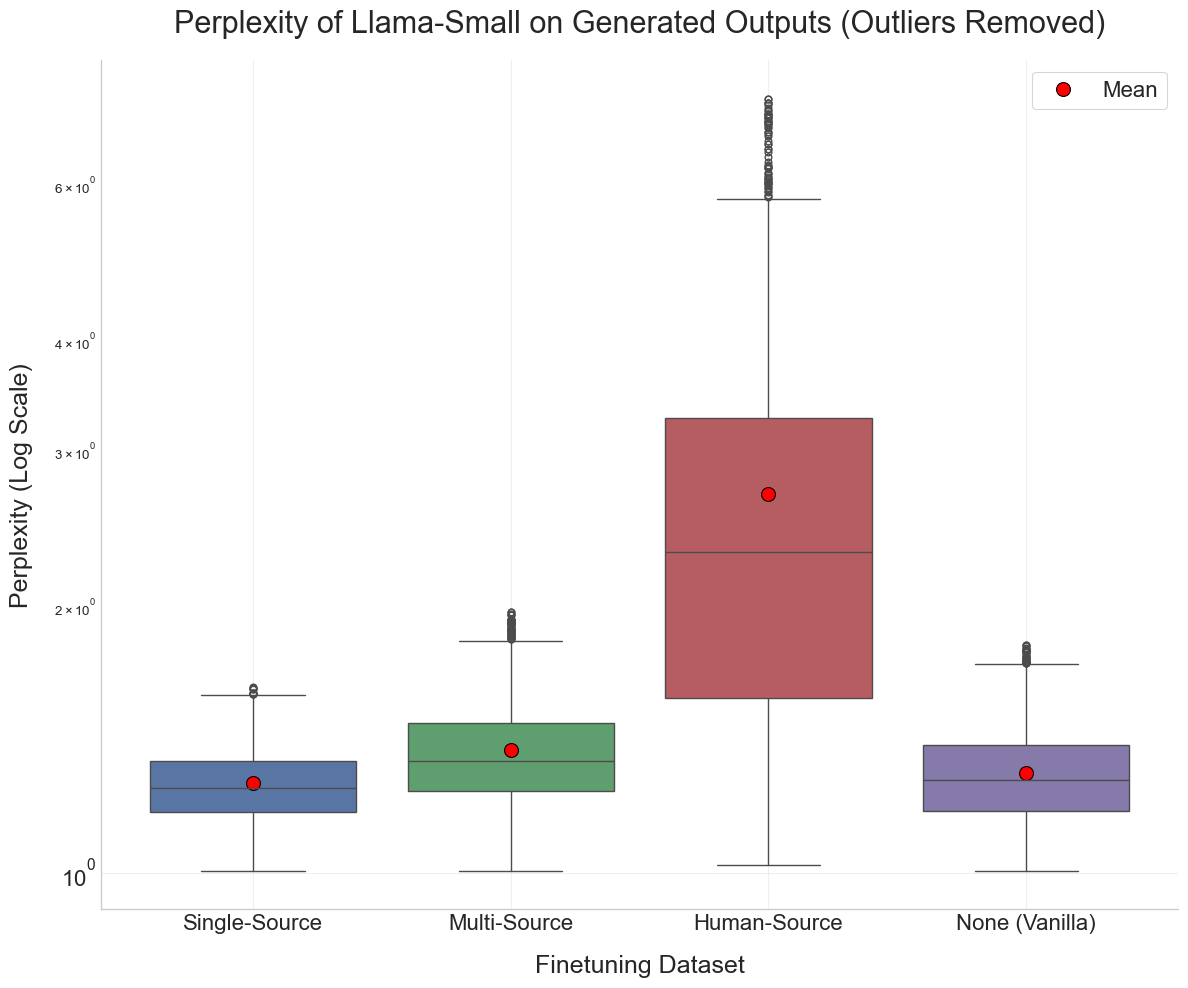

<Figure size 1200x1000 with 0 Axes>

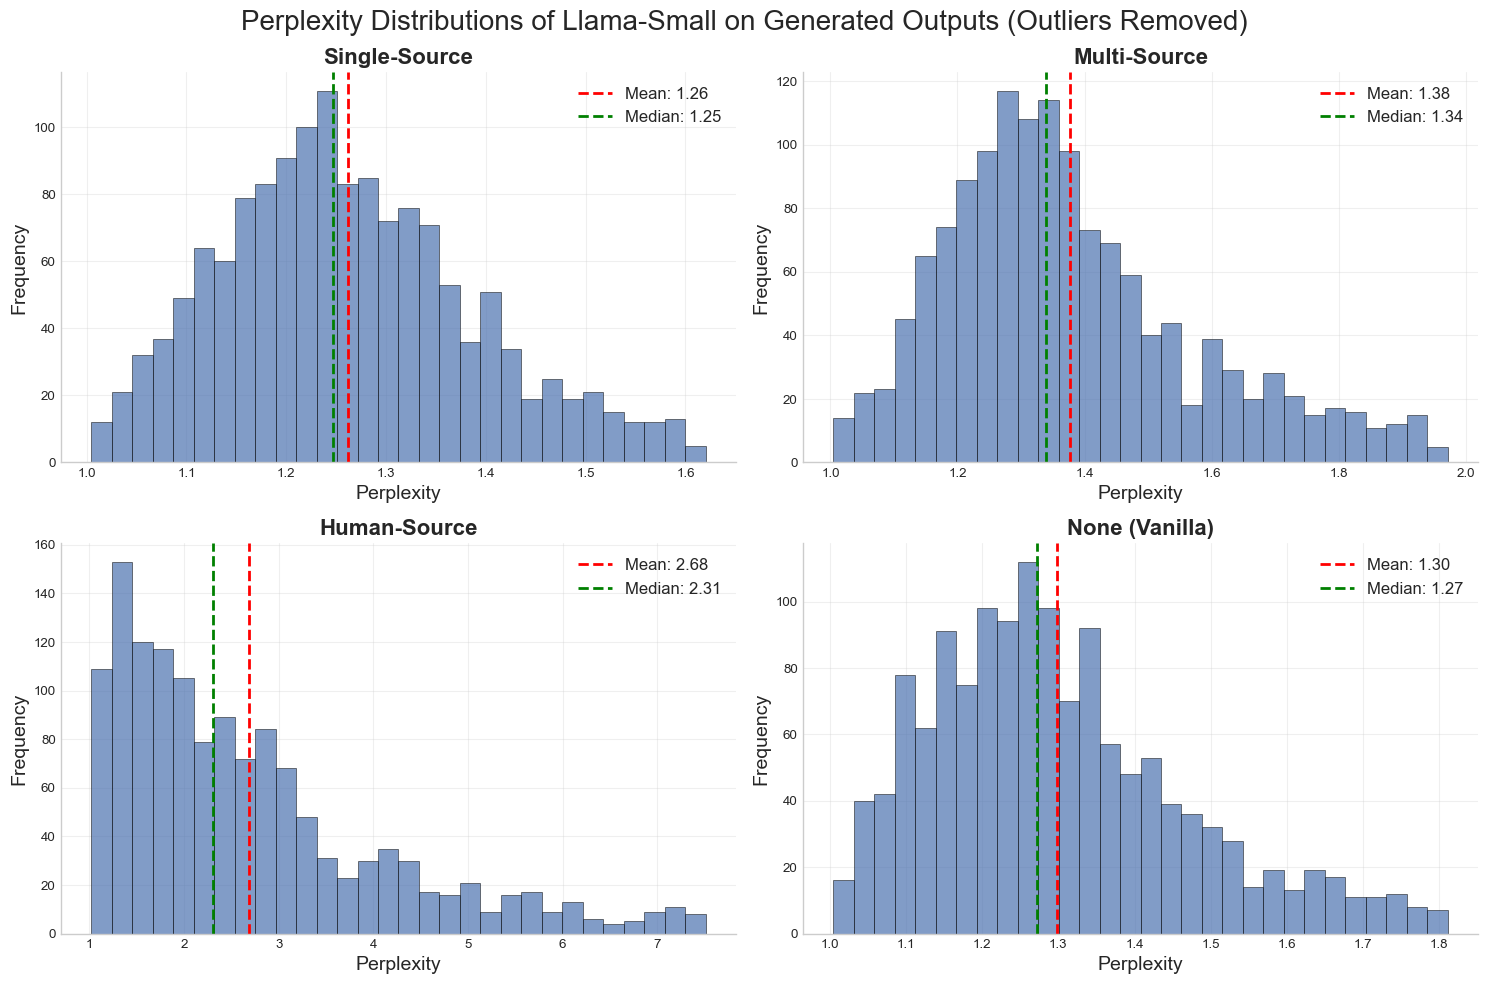


               Homogeneity of Variance (Levene's Test)                
Overall Test on groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
Statistic: 1145.4543, p-value: 0.000e+00
Result: The test is significant at alpha=0.05.

Pairwise Levene's with Bonferroni correction (alpha = 8.33e-03)
      Group 1        Group 2 Statistic   p-value  Significant
Single-Source   Multi-Source    163.74  1.73e-36         True
Single-Source   Human-Source   1272.73 5.09e-230         True
Single-Source None (Vanilla)     73.96  1.30e-17         True
 Multi-Source   Human-Source   1092.43 5.05e-202         True
 Multi-Source None (Vanilla)     22.02  2.83e-06         True
 Human-Source None (Vanilla)   1146.45 2.70e-210         True

             Difference in Distributions (Kruskal-Wallis)             
Overall Test on groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
Statistic: 1984.9153, p-value: 0.000e+00
Result: The test is significant at alpha=0.05.

Pairwise Mann-Wh

In [46]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "small"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("Multi-Source", "ppl_lora_llama_8b_multi.jsonl"),
    ("Human-Source", "ppl_lora_llama_8b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    
    # --- Perform Statistical Tests on Final Data ---
    levene_test_func = lambda *args: stats.levene(*args, center='median')
    run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")